# 9. Estrategias custom de opciones: payoff y griegas bajo distintos escenarios de volatilidad

Este notebook construye 14 estrategias custom (combinaciones de calls/puts vainilla vendidos y
comprados, via `q.both`/`q.when`/`q.cashflow`, mismo patron que el straddle/strangle de
`02_exotic_and_path_dependent_options.ipynb SS9`) y las somete a 6 escenarios de volatilidad
(`sigma` = 10%/15%/20%/25%/30%/40%) para ver como cambia, para cada una: el VALOR hoy (no solo
el payoff a vencimiento, que es vol-independiente), delta, gamma, theta, vega, y tres griegas de
segundo orden con interes financiero real: **vanna** (d^2V/dS dSigma, como cambia delta con la
vol, clave para libros con opcionalidad y smile), **volga**/vomma (d^2V/dSigma^2, convexidad
respecto a la vol, relevante para quien trada vol de la vol) y **charm** (d^2V/dS dt, el
"decaimiento de delta", critico para quien hace delta-hedging cerca de vencimiento).

## Las 14 estrategias

| Estrategia | Patas (call C / put P, strike, cantidad) | Intuicion |
|---|---|---|
| `buy_call` | C100 x+1 | Alcista, riesgo limitado a la prima, ganancia ilimitada |
| `sell_call` | C100 x-1 | Bajista/neutral, prima limitada, perdida ilimitada |
| `buy_put` | P100 x+1 | Bajista, riesgo limitado, ganancia acotada por S->0 |
| `sell_put` | P100 x-1 | Alcista/neutral, prima limitada, perdida grande si S cae |
| `long_straddle` | C100 x+1, P100 x+1 | Apuesta PURA por volatilidad (direccion-neutral) |
| `short_straddle` | C100 x-1, P100 x-1 | Apuesta a que el subyacente NO se mueva |
| `long_butterfly` | C90 x+1, C100 x-2, C110 x+1 | Apuesta a que S termine cerca de 100 (pin risk), CONTRA vol |
| `short_butterfly` | C90 x-1, C100 x+2, C110 x-1 | Apuesta a que S se mueva lejos de 100, A FAVOR de vol |
| `long_condor` | C85 x+1, C95 x-1, C105 x-1, C115 x+1 | Como butterfly, meseta mas ancha, menos pin risk |
| `short_condor` | C85 x-1, C95 x+1, C105 x+1, C115 x-1 | Espejo del condor largo |
| `long_calendar_spread` | C100(T_near) x-1, C100(T_far) x+1 | Apuesta al diferencial de decaimiento temporal entre plazos |
| `short_calendar_spread` | C100(T_near) x+1, C100(T_far) x-1 | Espejo del calendario largo |
| `call_ratio_spread` (1x2) | C100 x+1, C110 x-2 | Sesgo alcista moderado + corto de vol/gamma mas alla de K2 |
| `short_ratio_spread` | C100 x-1, C110 x+2 | Espejo: largo de vol/gamma mas alla de K2 |

Todas las estrategias salvo las dos de calendario comparten vencimiento `T = 1.0` (un unico
strike central ATM = 100). El calendario usa `T_near = 0.25` / `T_far = 1.0` sobre el mismo
strike ATM -- por construccion NO tiene un "payoff a vencimiento" unico (las dos patas vencen en
fechas distintas), asi que para esas dos estrategias se omite la curva de payoff intrinseco de
referencia (ver SS3).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import display, Markdown

import engine
import engine_typed as q
from engine_typed import greeks

print("modulo engine importado desde:", engine.__file__)

modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


In [2]:
OBS = "EQ.SPOT.XYZ"
S0, R, Q_DIV = 100.0, 0.03, 0.0
T_NEAR, T_FAR = 0.25, 1.0
T = T_FAR
VOLS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
VOL_BASE = 0.20
DT_CHARM = 1.0 / 365.0

eng = engine.Engine()
MARKET = engine.MarketSnapshot(pillars=[T_NEAR, T_FAR], zero_rates=[R, R])
EXECUTION = engine.ExecutionContext({"backend": "cpu"})

VALUE_PRICING = engine.PricingContext({"pricing_date": 0.0, "n_paths": 30_000.0, "n_steps": 1.0, "seed": 7.0})
GREEK_PRICING = engine.PricingContext({"pricing_date": 0.0, "n_paths": 20_000.0, "n_steps": 1.0, "seed": 7.0})
CHARM_PRICING = engine.PricingContext({"pricing_date": DT_CHARM, "n_paths": 20_000.0, "n_steps": 1.0, "seed": 7.0})

VOL_COLORS = cm.viridis(np.linspace(0.0, 0.9, len(VOLS)))

print(f"S0={S0}  R={R}  T={T}  VOLS={VOLS}")

S0=100.0  R=0.03  T=1.0  VOLS=[0.1, 0.15, 0.2, 0.25, 0.3, 0.4]


In [3]:
# Leg builders (ADR-P0-02: amount positivo = entrada de caja para el titular -- 'qty' positivo
# es comprado/largo, 'qty' negativo es vendido/corto, sin necesidad de q.give).
#
# Delegan en engine_typed.payoff.call_leg/put_leg/custom_strategy (PLAN_IMPROVE_NOTEBOOK2.md
# Fase 6): unica fuente de verdad para pata vainilla + combinador de estrategia, compartida con
# 02_exotic_and_path_dependent_options.ipynb -- antes cada notebook reimplementaba a mano el
# mismo patron when(T, cashflow(qty*max(...))) por su lado (el mismo riesgo de "isla" que
# PLAN_GREEKS.md SS0 senala para otra funcionalidad). Las versiones "_manual" de abajo son la
# implementacion local que usaba este notebook antes de Fase 6, conservadas como celda de
# verificacion cruzada (mismo patron editorial que 02_exotic_and_path_dependent_options.ipynb,
# no borradas sin mas).


def call_leg(strike, qty, maturity):
    return q.call_leg(OBS, strike, qty, maturity)


def put_leg(strike, qty, maturity):
    return q.put_leg(OBS, strike, qty, maturity)


def legs_for(strategy_legs):
    return [(call_leg if kind == "call" else put_leg)(strike, qty, maturity) for kind, strike, qty, maturity in strategy_legs]


def call_leg_manual(strike, qty, maturity):
    return q.when(maturity, q.cashflow("USD", qty * q.maximum(q.fixing(OBS, maturity) - strike, 0)))


def put_leg_manual(strike, qty, maturity):
    return q.when(maturity, q.cashflow("USD", qty * q.maximum(strike - q.fixing(OBS, maturity), 0)))


def build_contract_manual(strategy_legs):
    """Version local horneada a mano (PRE-Fase 6, celda de verificacion cruzada): mismas patas,
    combinadas con q.both(...) directamente en vez de q.custom_strategy."""
    pieces = [(call_leg_manual if kind == "call" else put_leg_manual)(strike, qty, maturity) for kind, strike, qty, maturity in strategy_legs]
    return q.both(pieces)


def intrinsic_value(legs, spot_grid):
    """Payoff intrinseco a un instante fijo (vencimiento, si todas las patas comparten
    maturity) via el motor real (PLAN_IMPROVE_NOTEBOOK2.md Fase 1): `Engine.evaluate_scenario`
    ejecuta el AST ya compilado de las patas (ScenarioEvaluator, PLAN_PRODUCTS.md SS5.1/SS5.2)
    sobre un escenario de spot fijo -- ya NO reimplementamos max(S-K,0)/max(K-S,0) a mano, el
    motor calcula, aqui solo se fija el spot. El binding acepta un unico escenario a la vez
    (dict {observable: spot}), asi que se recorre `spot_grid` en un bucle Python -- el calculo
    real de cada punto lo hace el motor, no NumPy (mismo patron que exige el enunciado de esta
    fase: "un bucle Python que igual delega el calculo real al motor").
    """
    trade = q.custom_strategy("INTRINSIC_VALUE_SCENARIO", legs_for(legs))
    product = eng.create_product(trade.product_type, trade.to_params())
    totals = np.empty(len(spot_grid), dtype=float)
    for i, spot in enumerate(spot_grid):
        ledger = eng.evaluate_scenario(product, {OBS: float(spot)})
        totals[i] = sum(amount for _time, _currency, amount in ledger)
    return totals


def intrinsic_value_manual(legs, spot_grid):
    """Formula NumPy pura (unica implementacion de `intrinsic_value` antes de Fase 1 de
    PLAN_IMPROVE_NOTEBOOK2.md): conservada como celda de verificacion cruzada, no como unico
    camino -- mismo criterio editorial que call_leg_manual/put_leg_manual/build_contract_manual
    de Fase 6, arriba."""
    total = np.zeros_like(spot_grid)
    for kind, strike, qty, _maturity in legs:
        if kind == "call":
            total = total + qty * np.maximum(spot_grid - strike, 0.0)
        else:
            total = total + qty * np.maximum(strike - spot_grid, 0.0)
    return total


# (kind, strike, qty, maturity) por pata -- unica fuente de verdad: de aqui salen tanto el
# Contract (motor) como el payoff intrinseco de referencia (numpy), nunca duplicados a mano.
STRATEGY_LEGS = {
    "buy_call": [("call", 100.0, 1.0, T)],
    "sell_call": [("call", 100.0, -1.0, T)],
    "buy_put": [("put", 100.0, 1.0, T)],
    "sell_put": [("put", 100.0, -1.0, T)],
    "long_straddle": [("call", 100.0, 1.0, T), ("put", 100.0, 1.0, T)],
    "short_straddle": [("call", 100.0, -1.0, T), ("put", 100.0, -1.0, T)],
    "long_butterfly": [("call", 90.0, 1.0, T), ("call", 100.0, -2.0, T), ("call", 110.0, 1.0, T)],
    "short_butterfly": [("call", 90.0, -1.0, T), ("call", 100.0, 2.0, T), ("call", 110.0, -1.0, T)],
    "long_condor": [("call", 85.0, 1.0, T), ("call", 95.0, -1.0, T), ("call", 105.0, -1.0, T), ("call", 115.0, 1.0, T)],
    "short_condor": [("call", 85.0, -1.0, T), ("call", 95.0, 1.0, T), ("call", 105.0, 1.0, T), ("call", 115.0, -1.0, T)],
    "long_calendar_spread": [("call", 100.0, -1.0, T_NEAR), ("call", 100.0, 1.0, T_FAR)],
    "short_calendar_spread": [("call", 100.0, 1.0, T_NEAR), ("call", 100.0, -1.0, T_FAR)],
    "call_ratio_spread": [("call", 100.0, 1.0, T), ("call", 110.0, -2.0, T)],
    "short_ratio_spread": [("call", 100.0, -1.0, T), ("call", 110.0, 2.0, T)],
}
CALENDAR_STRATEGIES = {"long_calendar_spread", "short_calendar_spread"}

PRODUCTS = {}
for name, legs in STRATEGY_LEGS.items():
    trade = q.custom_strategy(name.upper(), legs_for(legs))
    PRODUCTS[name] = eng.create_product(trade.product_type, trade.to_params())

# Verificacion cruzada: q.custom_strategy(call_leg/put_leg) (motor) vs build_contract_manual
# (q.both a mano, el patron que usaba este notebook antes de Fase 6) deben dar el MISMO precio
# exacto para TODAS las estrategias (misma seed/n_paths/modelo).
_check_model = eng.create_model("GBM", {"s0": S0, "r": R, "q": Q_DIV, "sigma": VOL_BASE, "observable": OBS})
for name, legs in STRATEGY_LEGS.items():
    manual_product = eng.create_product(
        "Payoff", q.PayoffProduct(id=f"{name.upper()}_MANUAL_CHECK", contract=build_contract_manual(legs)).to_params()
    )
    native_price = eng.price(PRODUCTS[name], ["PayoffPriceQ"], _check_model, MARKET, GREEK_PRICING, EXECUTION)["PayoffPriceQ"].scalar
    manual_price = eng.price(manual_product, ["PayoffPriceQ"], _check_model, MARKET, GREEK_PRICING, EXECUTION)["PayoffPriceQ"].scalar
    assert native_price == manual_price, f"{name}: custom_strategy={native_price} manual={manual_price}"

print(
    f"{len(PRODUCTS)} estrategias construidas: {list(PRODUCTS)} "
    f"(custom_strategy vs build_contract_manual: coinciden exactamente en las {len(STRATEGY_LEGS)} estrategias)"
)

# Verificacion cruzada (PLAN_IMPROVE_NOTEBOOK2.md Fase 1, criterio de aceptacion): para las 14
# estrategias (incluidas las dos de calendario, aunque su curva de payoff intrinseco no se
# dibuje en SS3 por tener dos vencimientos distintos) Engine.evaluate_scenario debe dar un
# resultado IDENTICO -- no solo "dentro de tolerancia" -- al de intrinsic_value_manual (NumPy).
_INTRINSIC_CHECK_GRID = np.linspace(60.0, 140.0, 41)
for name, legs in STRATEGY_LEGS.items():
    via_engine = intrinsic_value(legs, _INTRINSIC_CHECK_GRID)
    via_numpy = intrinsic_value_manual(legs, _INTRINSIC_CHECK_GRID)
    assert np.array_equal(via_engine, via_numpy), f"{name}: evaluate_scenario={via_engine} numpy={via_numpy}"
print(
    f"intrinsic_value (Engine.evaluate_scenario) vs intrinsic_value_manual (NumPy): coinciden "
    f"exactamente en las {len(STRATEGY_LEGS)} estrategias, grid de {len(_INTRINSIC_CHECK_GRID)} spots."
)


14 estrategias construidas: ['buy_call', 'sell_call', 'buy_put', 'sell_put', 'long_straddle', 'short_straddle', 'long_butterfly', 'short_butterfly', 'long_condor', 'short_condor', 'long_calendar_spread', 'short_calendar_spread', 'call_ratio_spread', 'short_ratio_spread'] (custom_strategy vs build_contract_manual: coinciden exactamente en las 14 estrategias)
intrinsic_value (Engine.evaluate_scenario) vs intrinsic_value_manual (NumPy): coinciden exactamente en las 14 estrategias, grid de 41 spots.


## Convencion de las griegas mostradas

`delta`/`vega` salen de una unica llamada a `Engine.all_greeks` (barrido automatico,
PLAN_GREEKS.md SS8.5). `gamma`/`vanna`/`volga` salen de `Engine.hessian` restringido a
`["model.spot", "model.volatility"]` (likelihood-ratio, una sola pasada Monte Carlo,
PLAN_BACKWARD.md): `gamma` = entrada `(spot,spot)`, `volga` = `(volatility,volatility)`, `vanna`
= la cruzada `(spot,volatility)`. `theta` se lee del propio `report.greeks` de `all_greeks`
(risk_factor `"time.theta"`) y se anualiza dividiendo por `bump_used` (mismo criterio que
`greeks.theta(annualized=True)`, PLAN_IMPROVE_NOTEBOOK.md Fase 4) -- **no** hace falta una
llamada aparte.

`charm` (d^2V/dS dt) es la unica griega que **no** puede salir de `Engine.hessian`:
`RiskFactorKind::TimeShift` esta excluido explicitamente de Hessiana/cruzadas en
`cpp/engine/include/engine/greeks.hpp` (comentario: "AAD de segundo orden... fuera de alcance").
Se calcula por diferencia finita de dos deltas en dos `PricingContext` con distinto
`pricing_date` (0 y `DT_CHARM` = 1 dia): `charm ~= (delta(t+dt) - delta(t)) / dt`, anualizado por
construccion (`dt` esta en anios).

**Nota (cerrado en PLAN_IMPROVE_NOTEBOOK2.md Fase 0):** la delta que ya usamos arriba (la de
`all_greeks`, `method="auto"`) resolvia -- antes de esa fase -- a la ruta especializada
*pathwise* para GBM+PayoffPriceQ+spot (`try_pathwise2` en `cpp/engine/src/greeks.cpp`), que solo
reenviaba `n_paths`/`seed` a Rust y por tanto ignoraba en silencio cualquier desplazamiento
temporal (asi se descubrio el bug: charm salia exactamente 0.0 para TODAS las estrategias). El
motor ahora rechaza esa especializacion explicitamente cuando `pricing.pricing_date() != 0`
(ADR-IN2-01): `method="auto"` cae solo al estencil de bump-and-reval (que SI reevalua la medida
completa con el `pricing_date` desplazado, misma via que ya usa `theta`), y `method="pathwise"`
explicito lanzaria un error claro en vez de un numero incorrecto. Las dos deltas de charm se
siguen pidiendo aqui con `method="bump_and_reval"` explicito -- **ya no como workaround de ese
bug (cerrado)**, sino porque sigue siendo, por diseno, la UNICA via genuina para un
desplazamiento de `pricing_date`: ninguna especializacion pathwise/likelihood-ratio cubre
`RiskFactorKind::TimeShift` (mismo motivo por el que `charm` tampoco sale de `Engine.hessian`,
ver arriba) -- fijar el metodo explicito documenta la intencion en vez de depender de que
`method="auto"` resuelva ahi por descarte.

In [4]:
def compute_greeks_grid(product, spot_grid):
    shape = (len(VOLS), len(spot_grid))
    out = {name: np.full(shape, np.nan) for name in ["delta", "gamma", "theta", "vega", "vanna", "volga", "charm"]}
    for vi, vol in enumerate(VOLS):
        for si, s in enumerate(spot_grid):
            model = eng.create_model("GBM", {"s0": float(s), "r": R, "q": Q_DIV, "sigma": float(vol), "observable": OBS})

            report = eng.all_greeks(product, "PayoffPriceQ", model, MARKET, GREEK_PRICING, EXECUTION)
            by_factor = {g.risk_factor: g for g in report.greeks}
            delta0 = by_factor["model.spot"].value
            out["delta"][vi, si] = delta0
            if "model.volatility" in by_factor:
                out["vega"][vi, si] = by_factor["model.volatility"].value
            if "time.theta" in by_factor:
                th = by_factor["time.theta"]
                out["theta"][vi, si] = th.value / th.bump_used

            hr = eng.hessian(
                product, "PayoffPriceQ", model, MARKET, GREEK_PRICING, EXECUTION,
                risk_factors=["model.spot", "model.volatility"],
            )
            by_pair = {(e.factor_i, e.factor_j): e.value for e in hr.entries}
            out["gamma"][vi, si] = by_pair.get(("model.spot", "model.spot"), np.nan)
            out["volga"][vi, si] = by_pair.get(("model.volatility", "model.volatility"), np.nan)
            out["vanna"][vi, si] = by_pair.get(
                ("model.spot", "model.volatility"), by_pair.get(("model.volatility", "model.spot"), np.nan)
            )

            # Charm: se piden ambas deltas con method="bump_and_reval" EXPLICITO por diseno,
            # no como workaround de un bug (PLAN_IMPROVE_NOTEBOOK2.md Fase 0, ya cerrada): la
            # especializacion pathwise (try_pathwise2 en cpp/engine/src/greeks.cpp) nunca cubrio
            # RiskFactorKind::TimeShift, y el motor ahora ademas la rechaza explicitamente
            # cuando pricing_date != 0 (antes de esta fase la ignoraba en silencio -- asi se
            # descubrio el bug: charm salia 0.0 para TODAS las estrategias). Se recalculan
            # AMBAS deltas con bump_and_reval (no se reutiliza el 'delta0' de all_greeks, que
            # usa method="auto"/pricing_date=0) para que la resta sea consistente entre si.
            delta_bump_t0 = eng.price(
                product, [greeks.delta("PayoffPriceQ", "spot", method="bump_and_reval").to_spec()],
                model, MARKET, GREEK_PRICING, EXECUTION,
            )["Greek"].scalar
            delta_bump_dt = eng.price(
                product, [greeks.delta("PayoffPriceQ", "spot", method="bump_and_reval").to_spec()],
                model, MARKET, CHARM_PRICING, EXECUTION,
            )["Greek"].scalar
            out["charm"][vi, si] = (delta_bump_dt - delta_bump_t0) / DT_CHARM
    return out


def value_curve(product, spot_grid, vol):
    models = [
        eng.create_model("GBM", {"s0": float(s), "r": R, "q": Q_DIV, "sigma": float(vol), "observable": OBS})
        for s in spot_grid
    ]
    grid = eng.price_grid([product], ["PayoffPriceQ"], models, [MARKET], VALUE_PRICING, EXECUTION)
    values = np.zeros(len(spot_grid))
    for cell in grid:
        values[cell.model_index] = cell.measures["PayoffPriceQ"].scalar
    return values


SPOT_GRID_VALUE = np.linspace(60.0, 140.0, 41)
SPOT_GRID_GREEKS = np.linspace(75.0, 125.0, 9)

GREEK_TITLES = {
    "delta": "Delta (dV/dS)", "gamma": "Gamma (d2V/dS2)", "theta": "Theta anualizada (dV/dt)",
    "vega": "Vega (dV/dSigma)", "vanna": "Vanna (d2V/dS dSigma)", "volga": "Volga (d2V/dSigma2)",
    "charm": "Charm anualizado (d2V/dS dt)",
}


def analyze_strategy(name, title):
    legs = STRATEGY_LEGS[name]
    product = PRODUCTS[name]
    is_calendar = name in CALENDAR_STRATEGIES

    # --- payoff intrinseco (solo si hay un unico vencimiento) + valor-hoy por escenario de vol ---
    fig, ax = plt.subplots(figsize=(8, 4.5))
    if not is_calendar:
        ax.plot(
            SPOT_GRID_VALUE, intrinsic_value(legs, SPOT_GRID_VALUE), color="black", linestyle="--",
            linewidth=1.5, label="payoff intrinseco (vencimiento)",
        )
    for vi, vol in enumerate(VOLS):
        ax.plot(SPOT_GRID_VALUE, value_curve(product, SPOT_GRID_VALUE, vol), color=VOL_COLORS[vi], label=f"valor hoy, sigma={vol:.0%}")
    ax.axhline(0.0, color="gray", linewidth=0.8)
    ax.axvline(S0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel("spot"); ax.set_ylabel("valor (USD)"); ax.set_title(f"{title}: payoff vs valor hoy")
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # --- griegas vs spot, 6 lineas (una por vol) ---
    grids = compute_greeks_grid(product, SPOT_GRID_GREEKS)
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.ravel()
    for gi, greek_name in enumerate(["delta", "gamma", "theta", "vega", "vanna", "volga", "charm"]):
        ax = axes[gi]
        for vi, vol in enumerate(VOLS):
            ax.plot(SPOT_GRID_GREEKS, grids[greek_name][vi], color=VOL_COLORS[vi], marker="o", markersize=3, label=f"{vol:.0%}")
        ax.axhline(0.0, color="gray", linewidth=0.7)
        ax.axvline(S0, color="gray", linewidth=0.7, linestyle=":")
        ax.set_title(GREEK_TITLES[greek_name], fontsize=10)
        ax.grid(alpha=0.3)
    axes[7].axis("off")
    axes[6].legend(loc="center left", bbox_to_anchor=(1.15, 0.5), fontsize=8, title="sigma")
    fig.suptitle(f"{title}: griegas vs spot, por escenario de volatilidad", y=1.02)
    plt.tight_layout(); plt.show()

    base_vi = VOLS.index(VOL_BASE)
    atm_si = int(np.argmin(np.abs(SPOT_GRID_GREEKS - S0)))
    summary = (
        f"**Observado (spot=ATM={SPOT_GRID_GREEKS[atm_si]:.0f}, sigma={VOL_BASE:.0%}):** "
        f"delta={grids['delta'][base_vi, atm_si]:+.3f}, "
        f"gamma={grids['gamma'][base_vi, atm_si]:+.4f}, "
        f"theta_anual={grids['theta'][base_vi, atm_si]:+.2f}, "
        f"vega={grids['vega'][base_vi, atm_si]:+.2f}, "
        f"vanna={grids['vanna'][base_vi, atm_si]:+.3f}, "
        f"volga={grids['volga'][base_vi, atm_si]:+.3f}, "
        f"charm_anual={grids['charm'][base_vi, atm_si]:+.3f}."
    )
    display(Markdown(summary))
    return grids

In [5]:
STRATEGY_TITLES = {"buy_call": "Buy Call", "sell_call": "Sell Call", "buy_put": "Buy Put", "sell_put": "Sell Put", "long_straddle": "Long Straddle", "short_straddle": "Short Straddle", "long_butterfly": "Long Butterfly", "short_butterfly": "Short Butterfly", "long_condor": "Long Condor", "short_condor": "Short Condor", "long_calendar_spread": "Long Calendar Spread", "short_calendar_spread": "Short Calendar Spread", "call_ratio_spread": "Call Ratio Spread (1x2)", "short_ratio_spread": "Short Ratio Spread (2x1)"}
STRATEGY_ORDER = ["buy_call", "sell_call", "buy_put", "sell_put", "long_straddle", "short_straddle", "long_butterfly", "short_butterfly", "long_condor", "short_condor", "long_calendar_spread", "short_calendar_spread", "call_ratio_spread", "short_ratio_spread"]

### `buy_call` -- call comprada (C100, x+1)

Esperado: perfil convexo, riesgo limitado a la prima pagada, ganancia ilimitada al alza. El
VALOR hoy debe subir con la vol en todo el rango de spot (mas valor tiempo). Delta creciente de
~0 (muy OTM) a ~1 (muy ITM), siempre >=0. Gamma y vega maximos cerca de ATM y caen en las colas.
Theta negativa en (casi) todo el rango -- el tiempo juega en contra del comprador. Vanna
positiva alrededor de ATM/OTM (subir la vol sube la probabilidad de terminar ITM, sube delta).

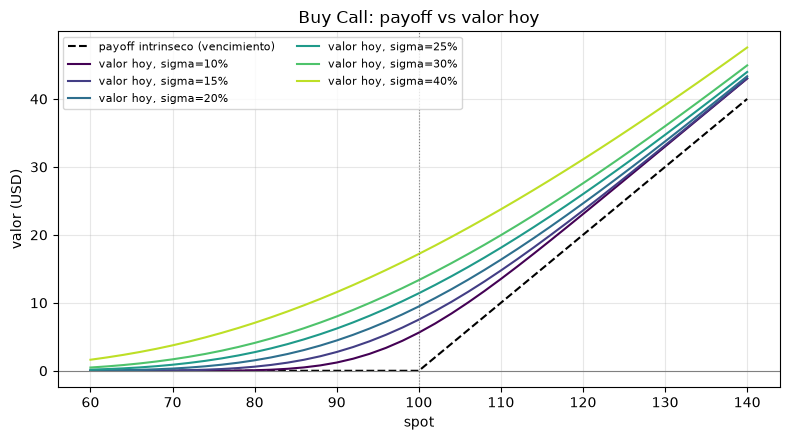

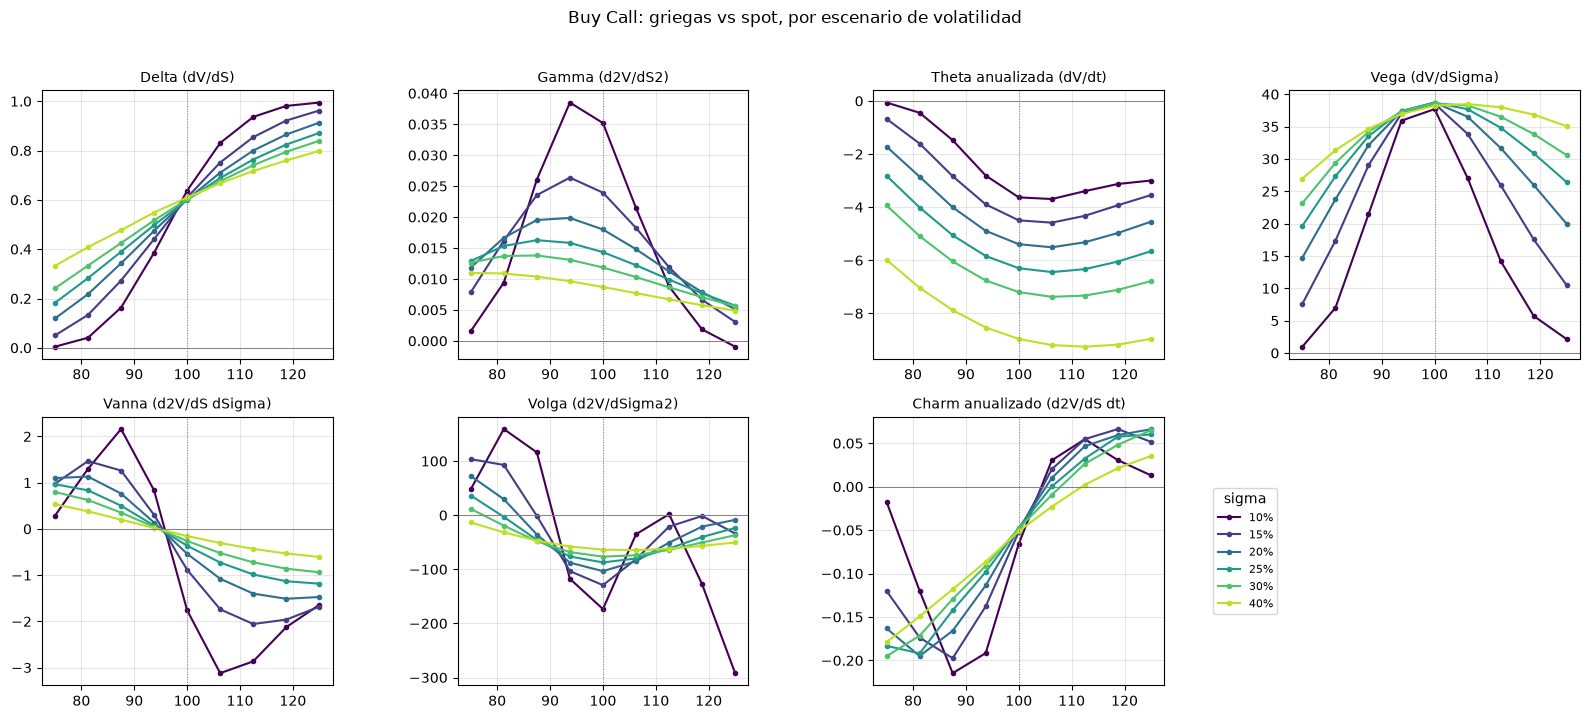

**Observado (spot=ATM=100, sigma=20%):** delta=+0.602, gamma=+0.0180, theta_anual=-5.40, vega=+38.72, vanna=-0.538, volga=-103.421, charm_anual=-0.048.

In [6]:
grids_buy_call = analyze_strategy("buy_call", "Buy Call")

### `sell_call` -- call vendida (C100, x-1)

Espejo exacto de `buy_call` con todos los signos invertidos: perdida potencialmente ilimitada,
delta negativa, gamma y vega negativas (el vendedor SUFRE si sube la vol), pero theta POSITIVA
(cobra por el paso del tiempo, la razon clasica de vender opciones "para generar income"). Vanna
y volga tambien con signo opuesto a `buy_call`.

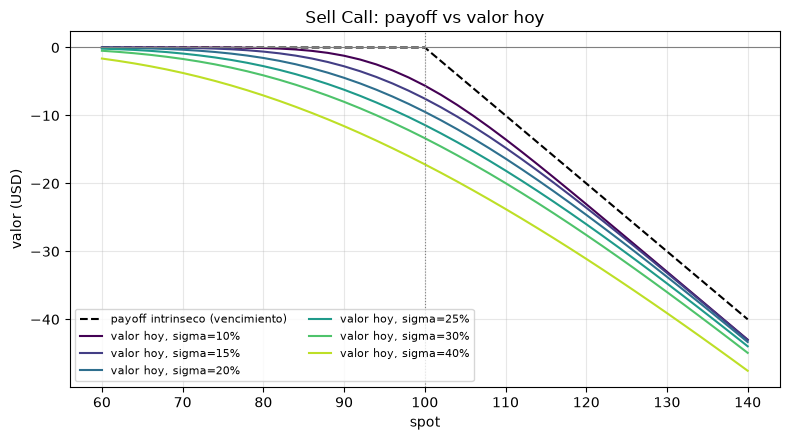

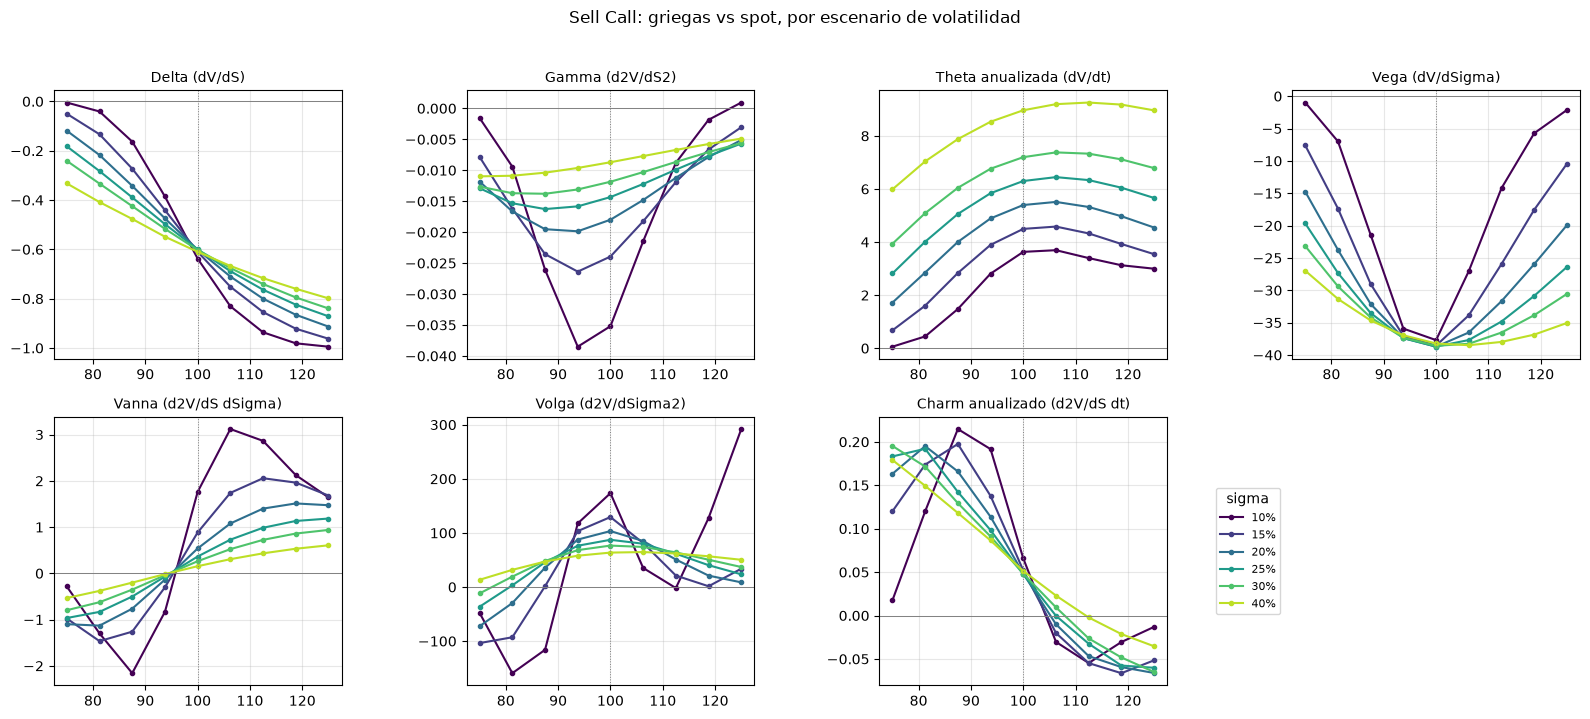

**Observado (spot=ATM=100, sigma=20%):** delta=-0.602, gamma=-0.0180, theta_anual=+5.40, vega=-38.72, vanna=+0.538, volga=+103.421, charm_anual=+0.048.

In [7]:
grids_sell_call = analyze_strategy("sell_call", "Sell Call")

### `buy_put` -- put comprada (P100, x+1)

Mismo patron convexo que `buy_call` pero orientado a la baja: delta negativa que va de ~0 (muy
ITM... es decir spot muy alto) a ~-1 (spot muy bajo). Ganancia acotada (maximo cuando S->0),
perdida limitada a la prima. Gamma/vega positivas y maximas ATM igual que la call (put y call del
mismo strike comparten gamma/vega por put-call parity). Theta negativa.

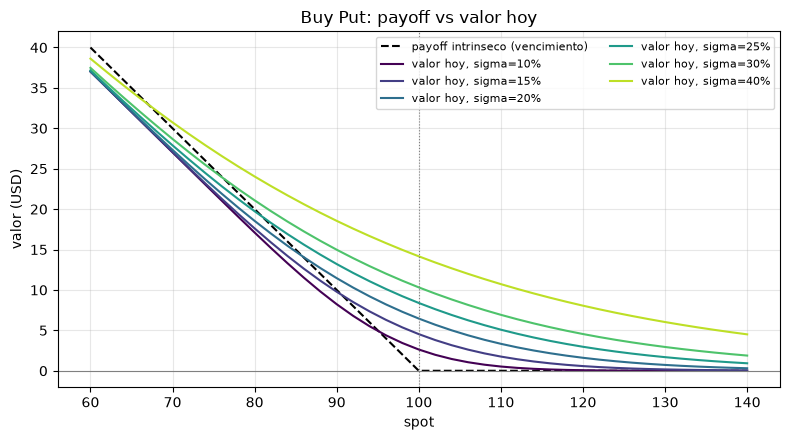

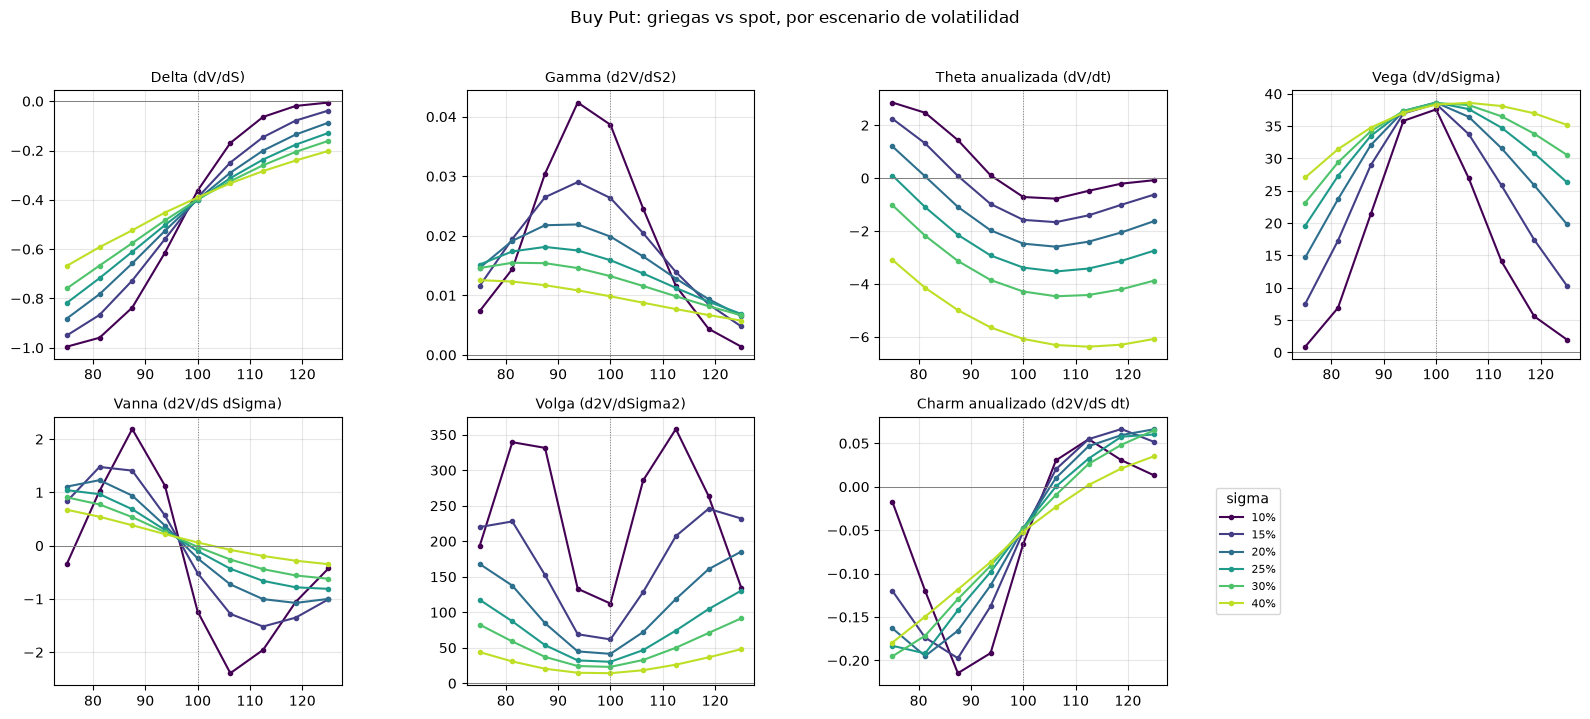

**Observado (spot=ATM=100, sigma=20%):** delta=-0.399, gamma=+0.0199, theta_anual=-2.48, vega=+38.64, vanna=-0.239, volga=+41.470, charm_anual=-0.048.

In [8]:
grids_buy_put = analyze_strategy("buy_put", "Buy Put")

### `sell_put` -- put vendida (P100, x-1)

Espejo de `buy_put`: delta positiva, gamma/vega negativas, theta positiva. Riesgo grande si el
spot cae con fuerza (perdida casi tan grande como el nocional menos la prima cobrada) -- el
patron clasico de "vender puts para comprar la accion mas barata" visto desde el riesgo de cola.

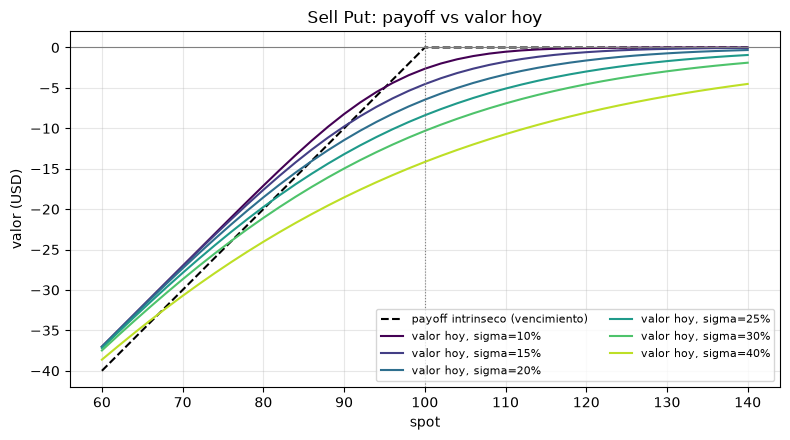

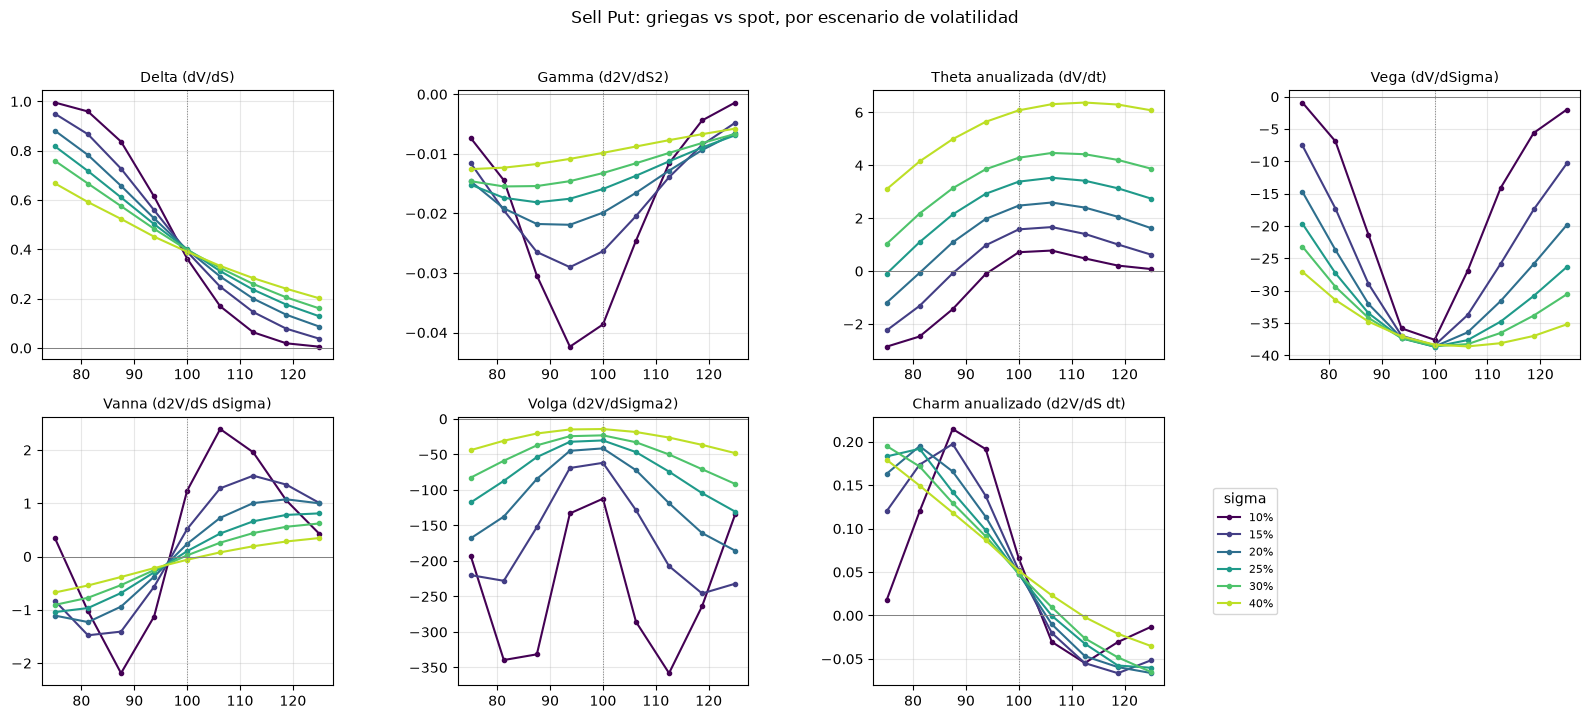

**Observado (spot=ATM=100, sigma=20%):** delta=+0.399, gamma=-0.0199, theta_anual=+2.48, vega=-38.64, vanna=+0.239, volga=-41.470, charm_anual=+0.048.

In [9]:
grids_sell_put = analyze_strategy("sell_put", "Sell Put")

### `long_straddle` -- call+put ATM comprados (apuesta PURA por volatilidad)

Delta-neutral ATM (~0) por construccion (call y put del mismo strike se cancelan en delta cerca
de ATM). El VALOR hoy debe ser la posicion MAS sensible a vol de toda la bateria: sube
monotonamente y con fuerza con sigma para cualquier spot. Gamma y vega maximos y ambos POSITIVOS
en ATM (posicion "larga de gamma/vega" clasica). Theta muy negativa cerca de ATM -- el straddle
"sangra" valor tiempo rapido si el subyacente no se mueve. Vanna deberia ser pequena/casi cero
exactamente en ATM (la vanna de la call y la de la put del mismo strike tienden a cancelarse ahi)
pero no nula fuera de ATM. Volga positiva (conviene la convexidad en vol).

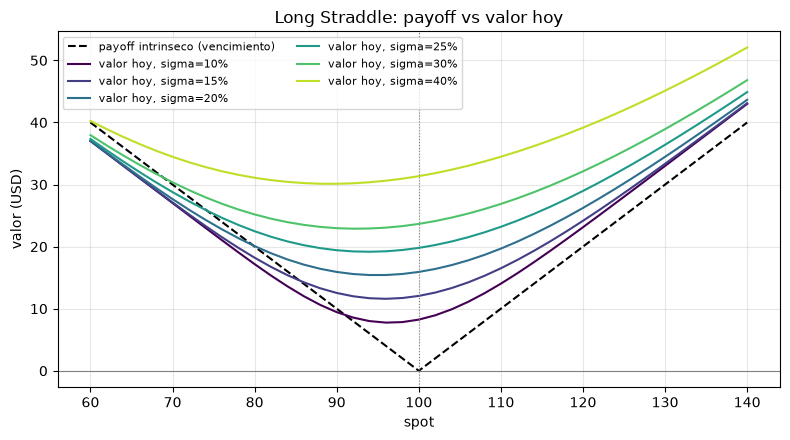

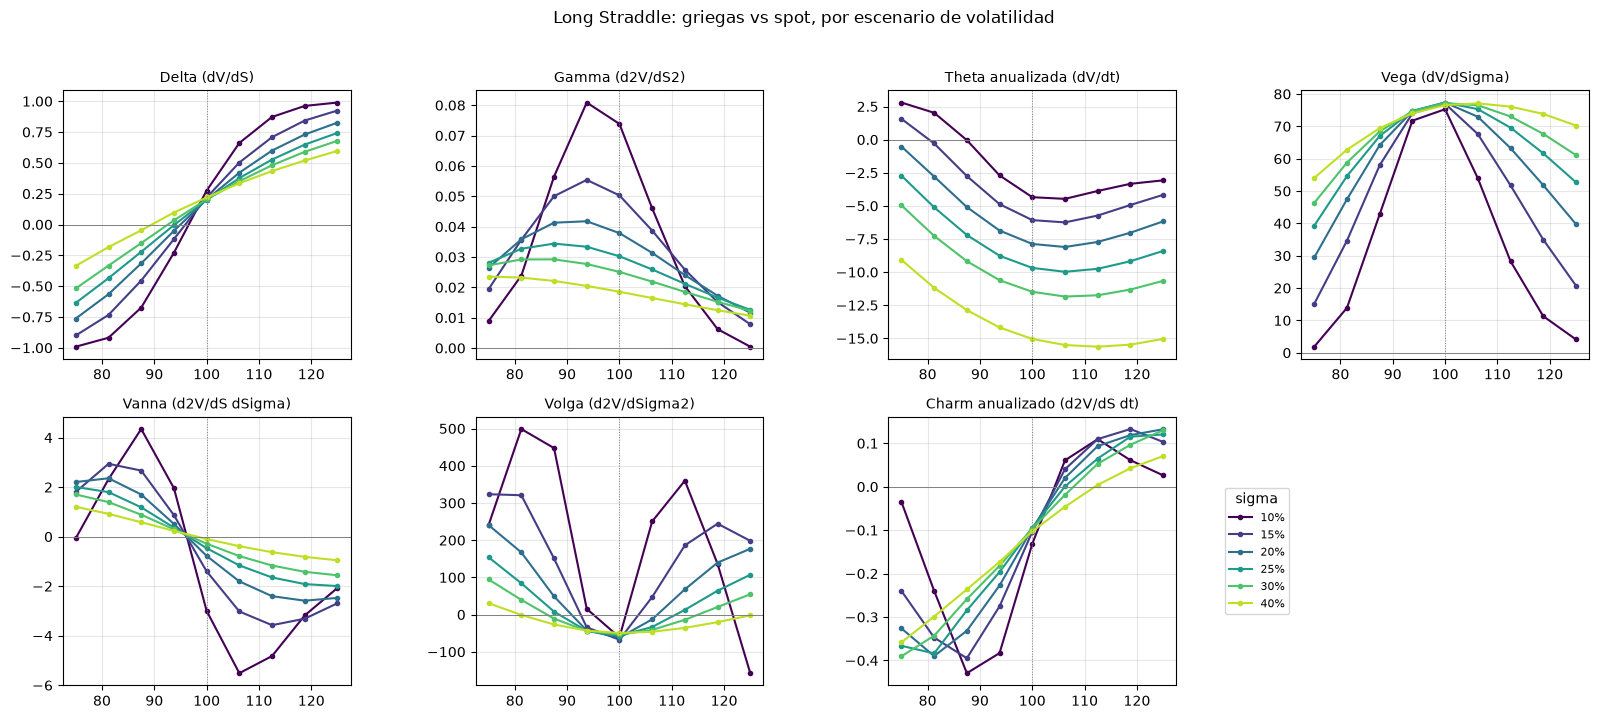

**Observado (spot=ATM=100, sigma=20%):** delta=+0.203, gamma=+0.0379, theta_anual=-7.87, vega=+77.36, vanna=-0.777, volga=-61.951, charm_anual=-0.096.

In [10]:
grids_long_straddle = analyze_strategy("long_straddle", "Long Straddle")

### `short_straddle` -- call+put ATM vendidos (apuesta a que NO se mueva)

Espejo exacto de `long_straddle`: gamma/vega negativas y minimas (mas negativas) en ATM, theta
positiva y maxima en ATM (cobra el mayor decaimiento temporal ahi), vanna/volga con signo
opuesto. Riesgo de cola grande si el subyacente se mueve mucho en cualquier direccion -- perfil
"vender vol" clasico.

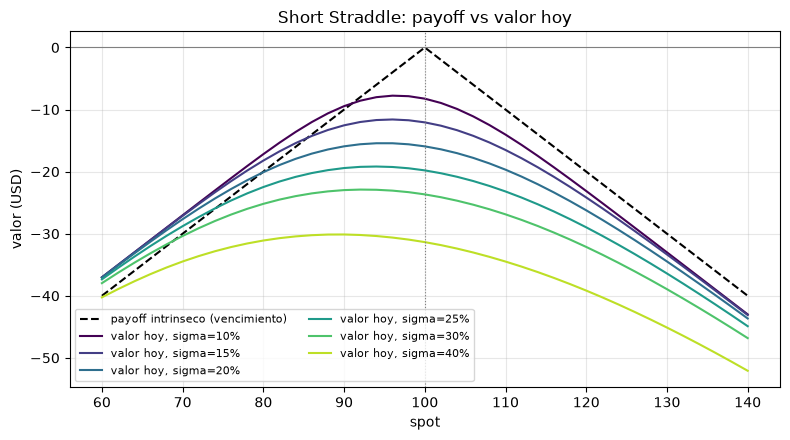

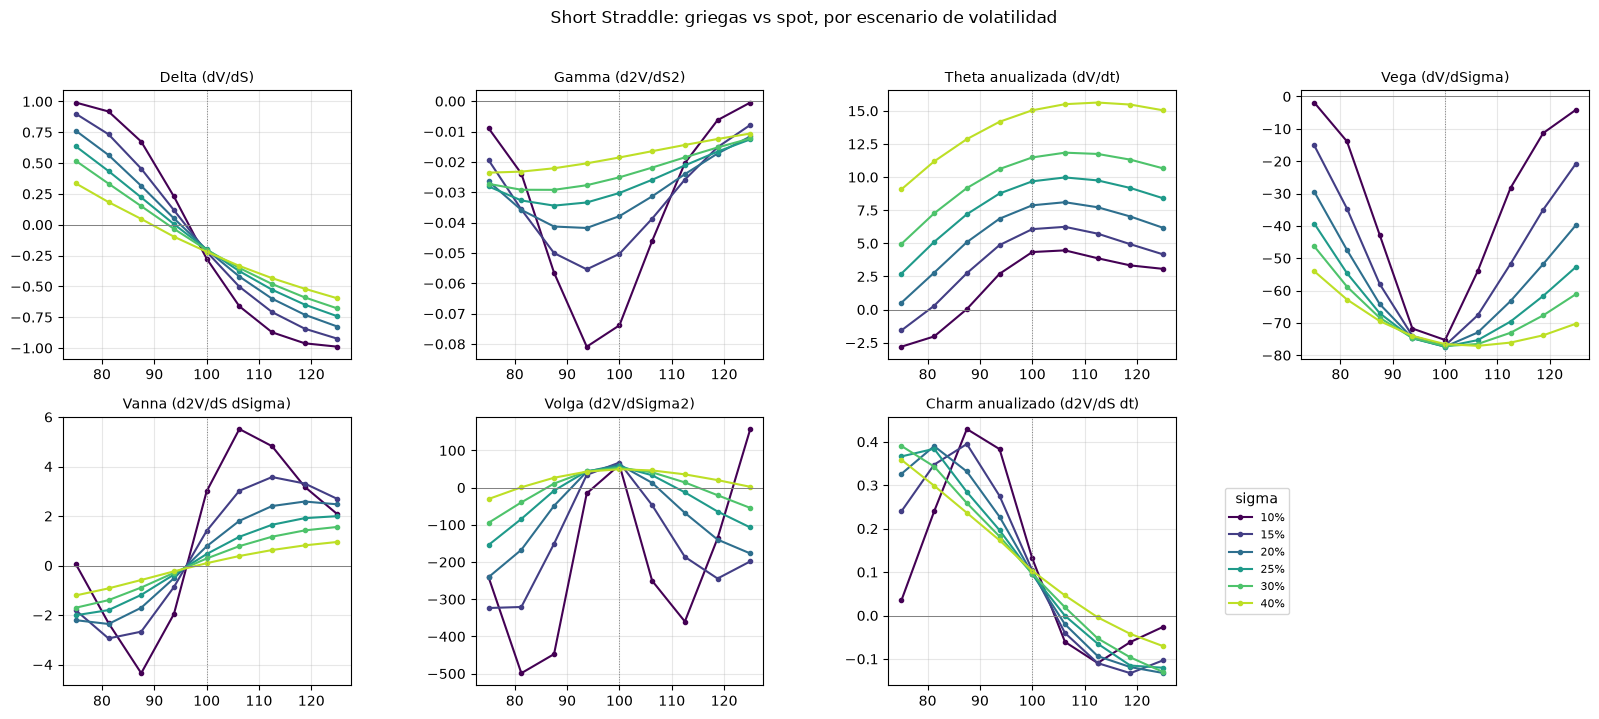

**Observado (spot=ATM=100, sigma=20%):** delta=-0.203, gamma=-0.0379, theta_anual=+7.87, vega=-77.36, vanna=+0.777, volga=+61.951, charm_anual=+0.096.

In [11]:
grids_short_straddle = analyze_strategy("short_straddle", "Short Straddle")

### `long_butterfly` -- call fly 90/100/110 (x+1/-2/+1), apuesta CONTRA la vol

A diferencia del straddle, aqui MAS vol es malo: el valor hoy deberia ser MAYOR cuando la vol es
BAJA (mayor probabilidad de que S termine cerca de 100, donde esta el pago maximo) y caer al
subir sigma (el "pin risk" en 100 se diluye si el subyacente puede moverse mucho). Gamma NEGATIVA
en el cuerpo (entre las alas, cerca de 100) y positiva en los extremos -- perfil de gamma en
forma de "M" invertida. Vega negativa cerca del centro. Theta POSITIVA cerca de 100 (gana con el
paso del tiempo si el spot se queda clavado ahi), a diferencia de una opcion comprada simple.

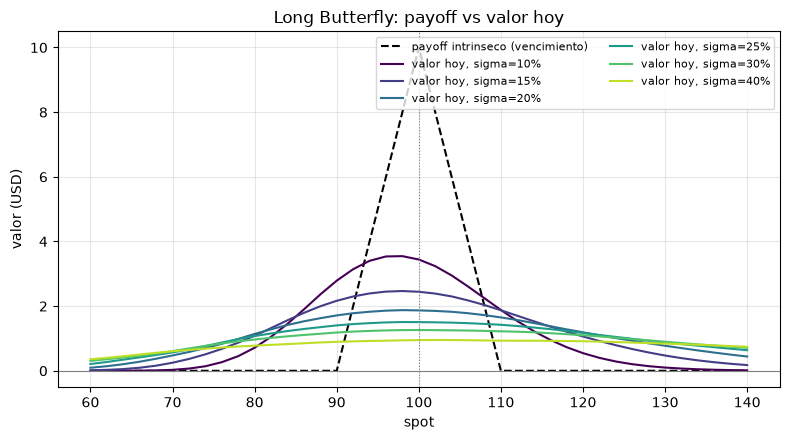

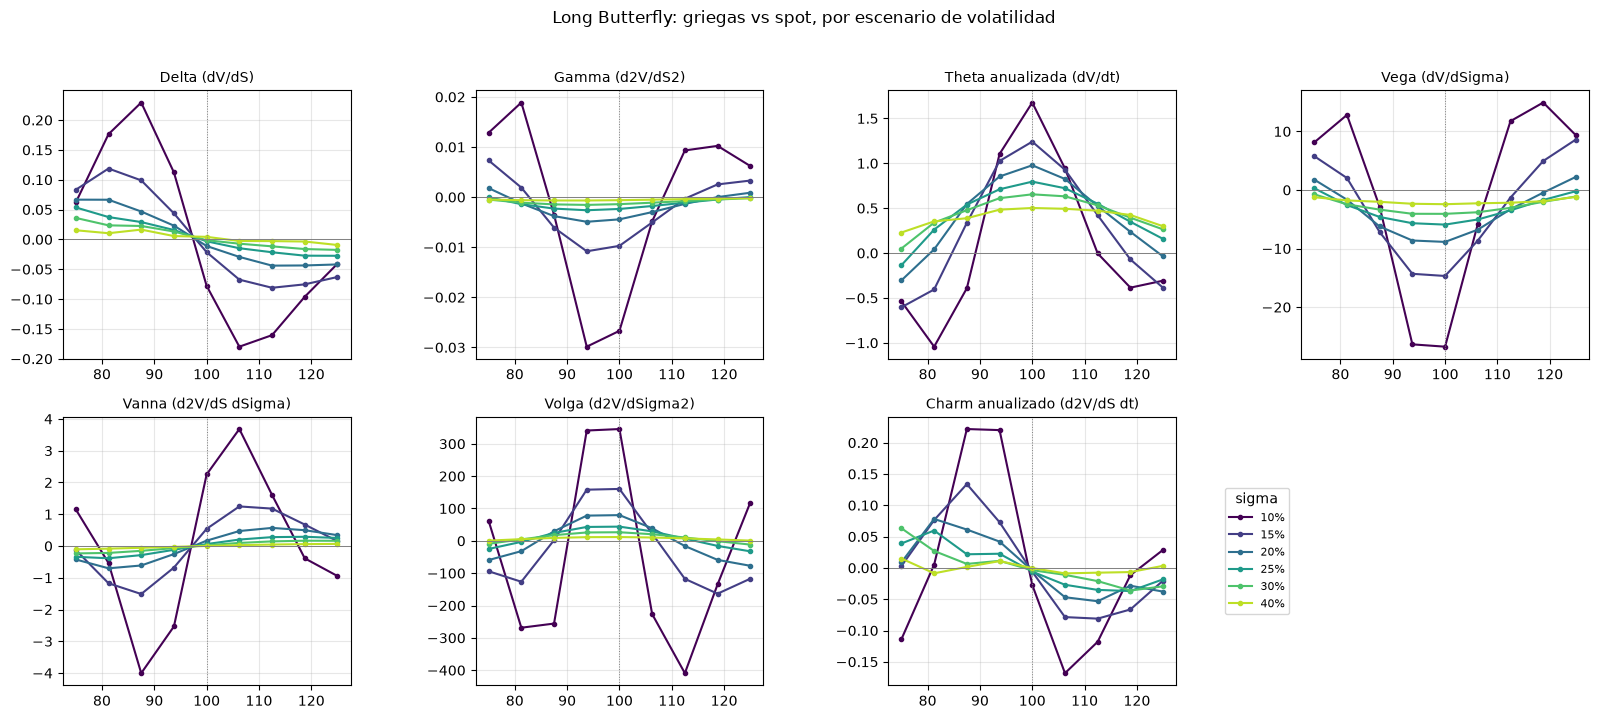

**Observado (spot=ATM=100, sigma=20%):** delta=-0.011, gamma=-0.0044, theta_anual=+0.98, vega=-8.86, vanna=+0.169, volga=+79.504, charm_anual=-0.004.

In [12]:
grids_long_butterfly = analyze_strategy("long_butterfly", "Long Butterfly")

### `short_butterfly` -- espejo del butterfly largo, apuesta A FAVOR de la vol

Todo invertido: valor hoy sube con sigma, gamma positiva en el cuerpo/negativa en las alas, vega
positiva cerca del centro, theta negativa cerca de 100. Gana si el subyacente se mueve lejos de
100 o si sube la vol; pierde (limitado) si el spot se queda pinneado en 100.

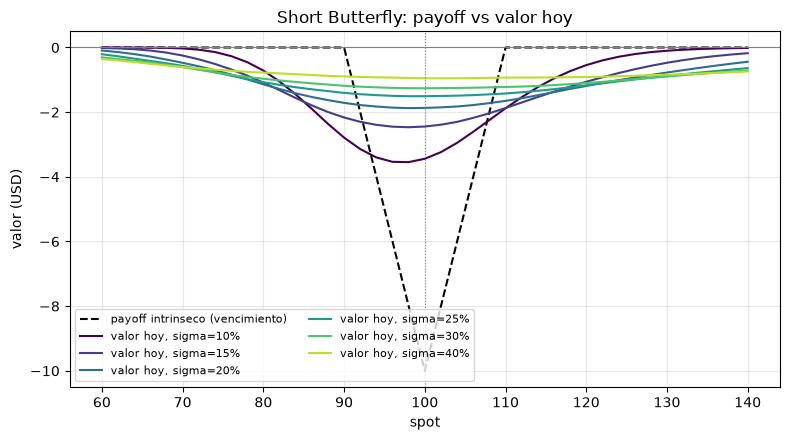

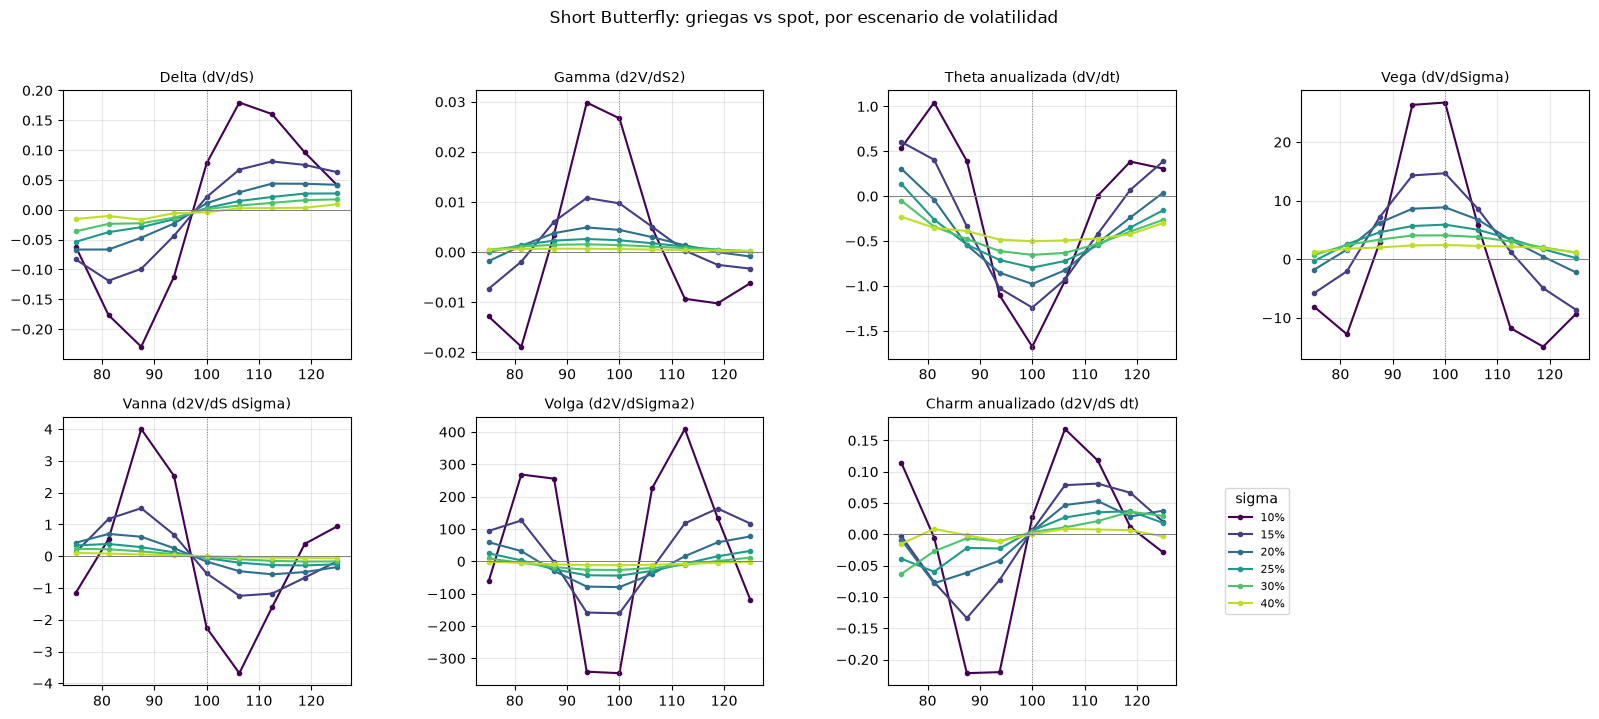

**Observado (spot=ATM=100, sigma=20%):** delta=+0.011, gamma=+0.0044, theta_anual=-0.98, vega=+8.86, vanna=-0.169, volga=-79.504, charm_anual=+0.004.

In [13]:
grids_short_butterfly = analyze_strategy("short_butterfly", "Short Butterfly")

### `long_condor` -- 85/95/105/115 (x+1/-1/-1/+1), como butterfly con meseta ancha

Misma logica que `long_butterfly` (apuesta contra la vol, gana con vol baja y spot dentro del
rango 95-105) pero con una meseta de beneficio maximo mas ancha y menos sensible al pin risk
exacto de un unico strike. Gamma/vega deberian ser negativas en el cuerpo y theta positiva
dentro del rango central -- pero la magnitud pico relativa al butterfly NO esta clara a priori
(depende de como compense la mayor anchura con la menor concentracion): se deja como pregunta
abierta para contrastar contra el numero real de la celda de abajo, no como afirmacion previa.

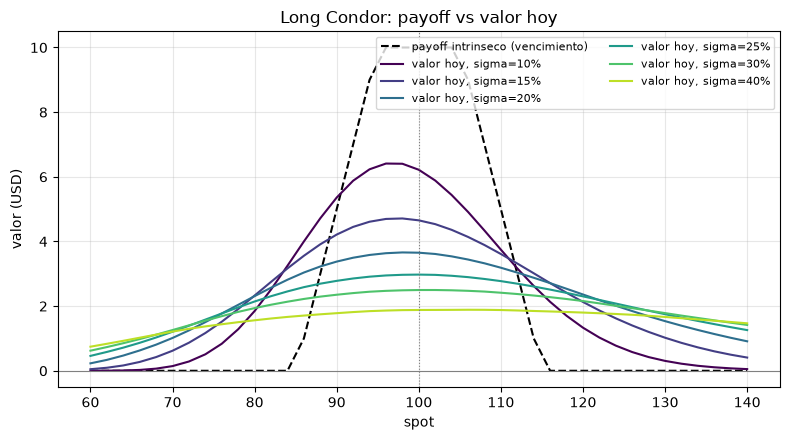

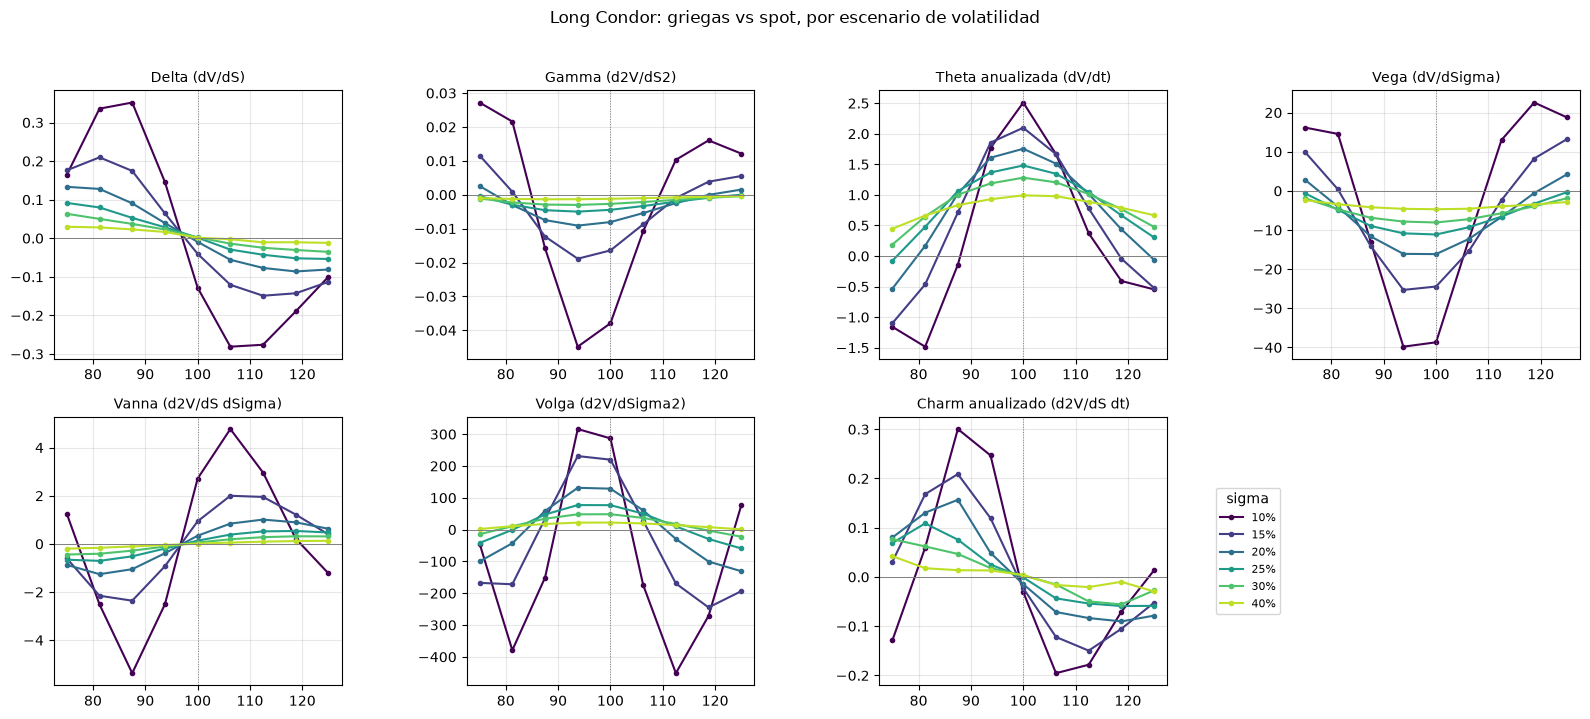

**Observado (spot=ATM=100, sigma=20%):** delta=-0.009, gamma=-0.0081, theta_anual=+1.75, vega=-16.15, vanna=+0.340, volga=+128.754, charm_anual=-0.015.

In [14]:
grids_long_condor = analyze_strategy("long_condor", "Long Condor")

### `short_condor` -- espejo del condor largo

Gana con vol alta o movimientos grandes fuera del rango 85-115, pierde (limitado) si el spot se
queda dentro. Gamma/vega positivas dentro del rango, theta negativa ahi mismo.

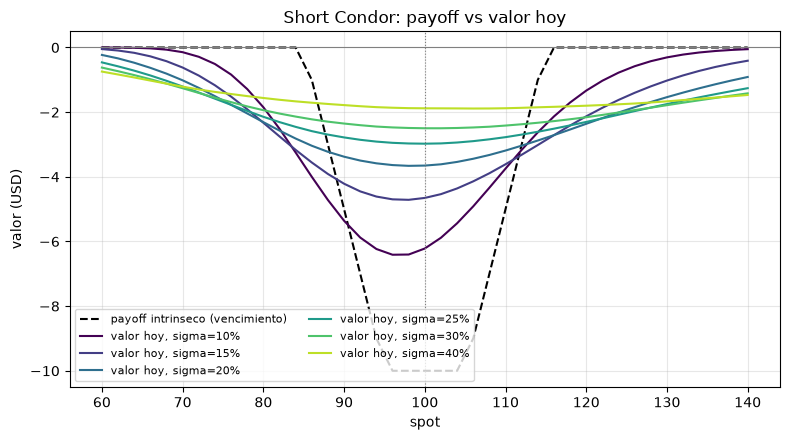

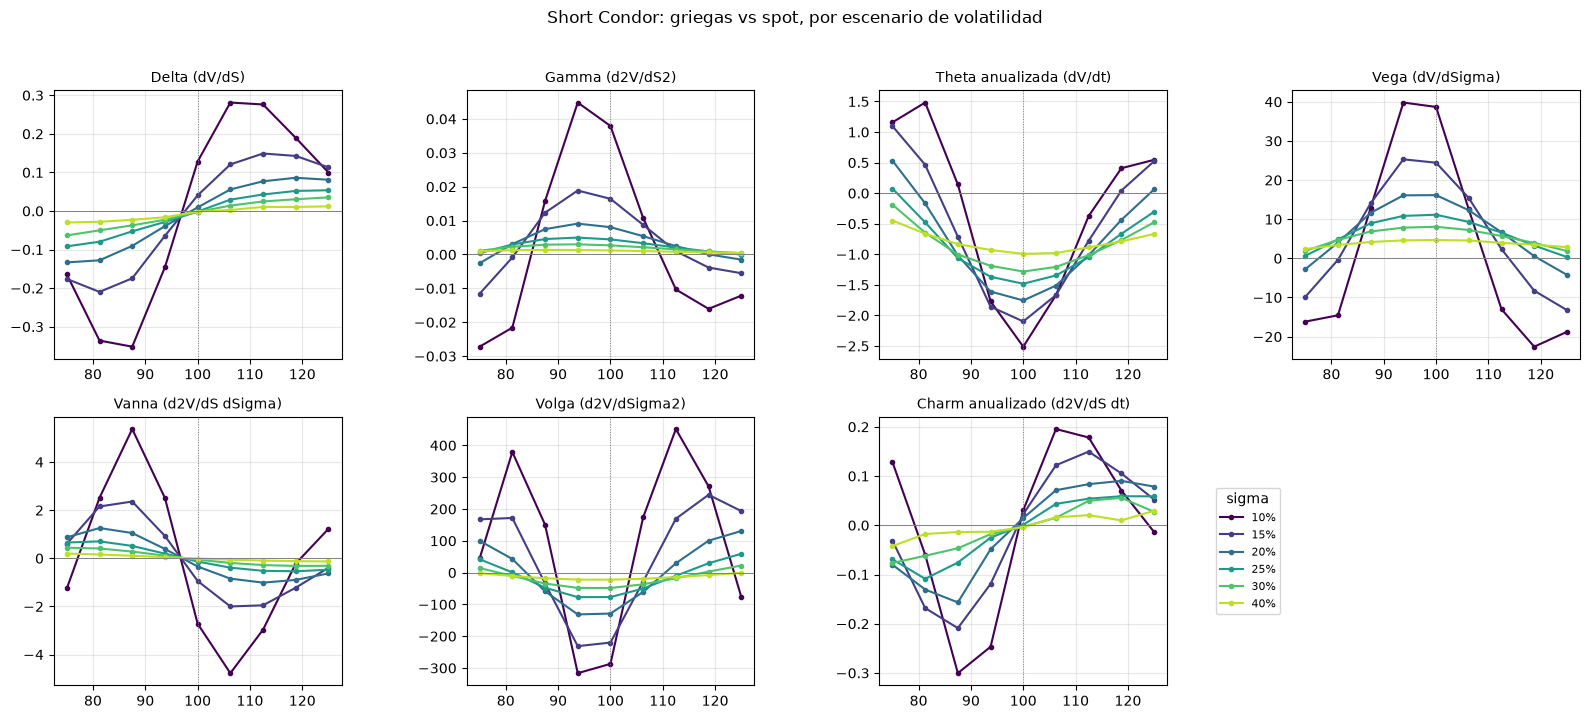

**Observado (spot=ATM=100, sigma=20%):** delta=+0.009, gamma=+0.0081, theta_anual=-1.75, vega=+16.15, vanna=-0.340, volga=-128.754, charm_anual=+0.015.

In [15]:
grids_short_condor = analyze_strategy("short_condor", "Short Condor")

### `long_calendar_spread` -- corto C100 a T_near=0.25, largo C100 a T_far=1.0

**Sin payoff intrinseco de referencia** (dos vencimientos distintos, no hay un S_T unico -- ver
nota de SS0). Esta estrategia es una apuesta pura a la ESTRUCTURA TEMPORAL: la pata larga (mas
lejana) tiene mas vega que la corta (mas cercana), asi que la vega NETA deberia ser POSITIVA --
sube con la vol igual que un straddle, aunque de forma mas moderada. Cerca de ATM y con el
tiempo pasando, la pata corta decae mas rapido que la larga, lo que puede dar una theta NETA
positiva si el spot se queda cerca de 100 (el clasico "calendario gana con el tiempo si no pasa
nada"). Muy sensible a que el spot se aleje del strike antes de T_near.

**Nota tecnica:** `gamma`/`vanna`/`volga` saldran `NaN` para los dos calendarios en la tabla/graficos de abajo -- `Engine.hessian` (likelihood-ratio, una sola pasada Monte Carlo) solo cubre contratos que dependen de una UNICA fecha terminal (mismo criterio que excluye `ContractOp::Exercise`); un calendario tiene dos fechas de fixing distintas, asi que esas tres griegas de segundo orden no estan disponibles con el metodo actual del motor para esta estrategia (no es un fallo del notebook, es un limite documentado de la ruta LRM).

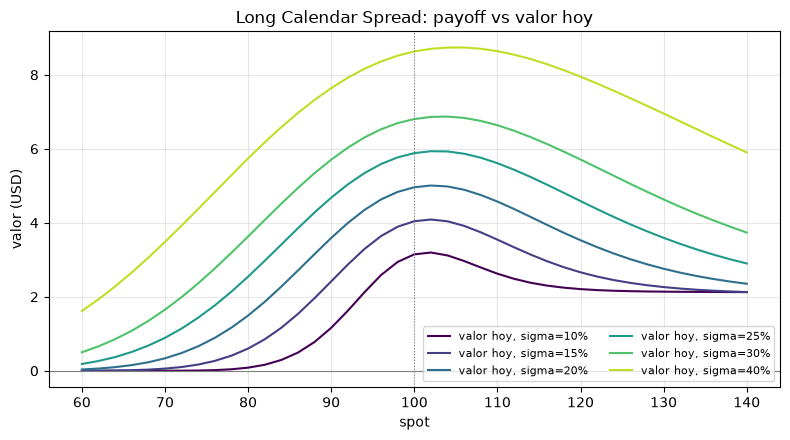

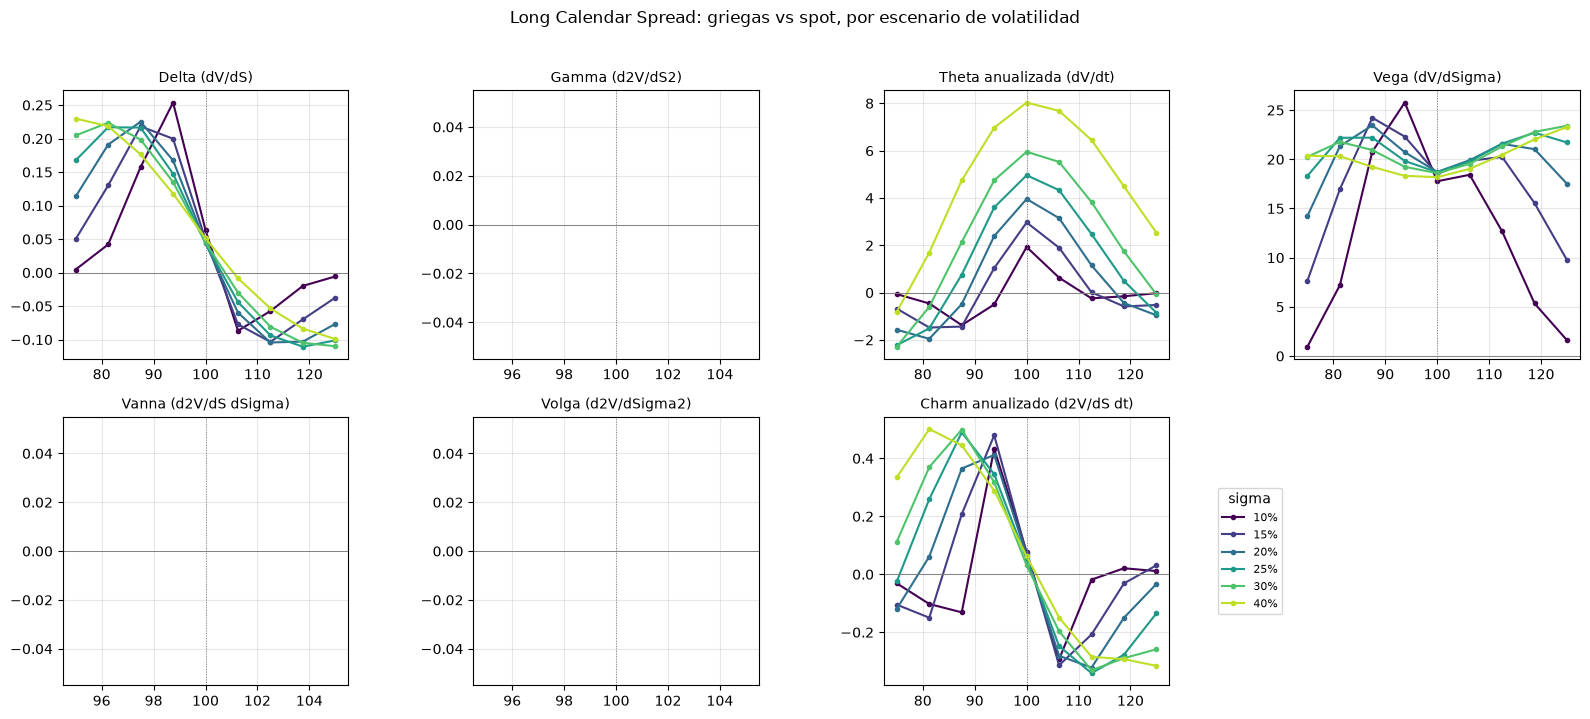

**Observado (spot=ATM=100, sigma=20%):** delta=+0.044, gamma=+nan, theta_anual=+3.96, vega=+18.71, vanna=+nan, volga=+nan, charm_anual=+0.064.

In [16]:
grids_long_calendar_spread = analyze_strategy("long_calendar_spread", "Long Calendar Spread")

### `short_calendar_spread` -- espejo del calendario largo

Vega neta negativa (pierde con vol alta), busca que el spot se ALEJE de 100 antes de T_near o
que la vol caiga. Menos intuitivo que las demas estrategias "cortas" porque no invierte el
payoff de un vencimiento unico, invierte la exposicion neta a la estructura temporal de vol.

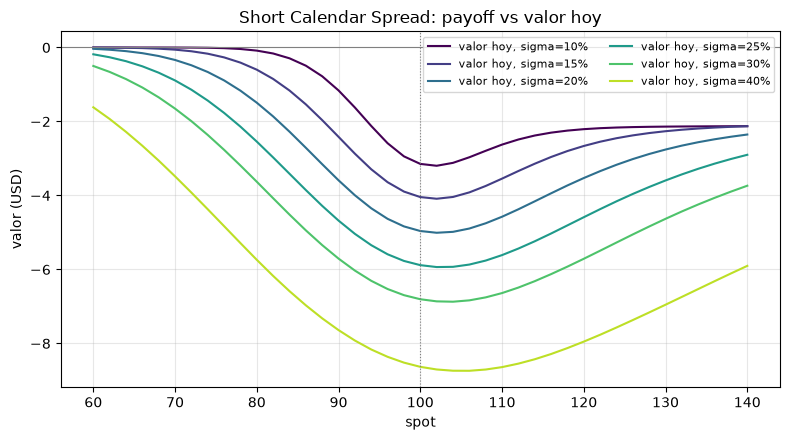

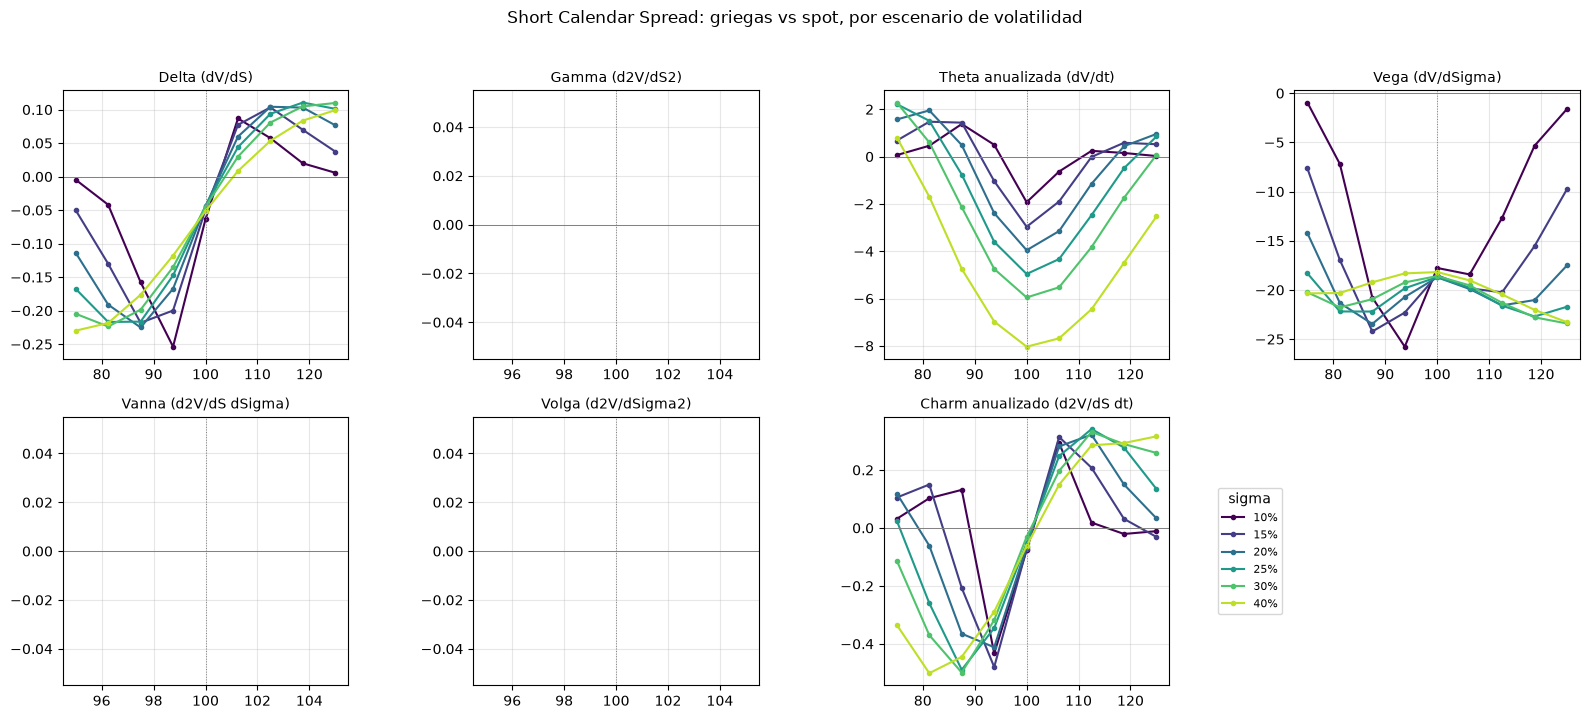

**Observado (spot=ATM=100, sigma=20%):** delta=-0.044, gamma=+nan, theta_anual=-3.96, vega=-18.71, vanna=+nan, volga=+nan, charm_anual=-0.064.

In [17]:
grids_short_calendar_spread = analyze_strategy("short_calendar_spread", "Short Calendar Spread")

### `call_ratio_spread` (1x2) -- largo C100, corto 2x C110

Sesgo alcista MODERADO: gana en un rango entre 100 y (aprox) 2*110-100=120, pero por encima de
~120 la perdida crece SIN LIMITE (2 calls vendidas dominan a 1 comprada) -- delta positiva cerca
de ATM que se vuelve NEGATIVA muy al alza (a diferencia de una call comprada simple, que siempre
tiene delta>=0). Gamma probablemente negativa por encima de 110 (la posicion neta esta corta de
opciones ahi) y vega neta probablemente negativa en conjunto (2 calls cortas > 1 call larga,
aunque la larga esta mas ITM y por tanto tiene menos vega de por si) -- posicion neta corta de
volatilidad mas alla de K2=110.

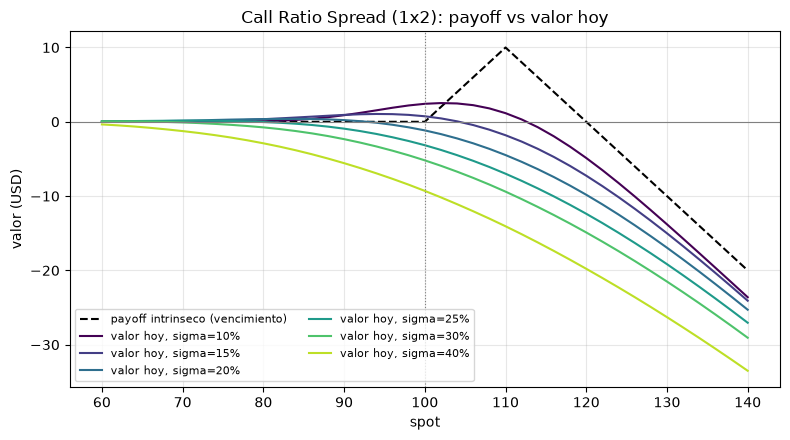

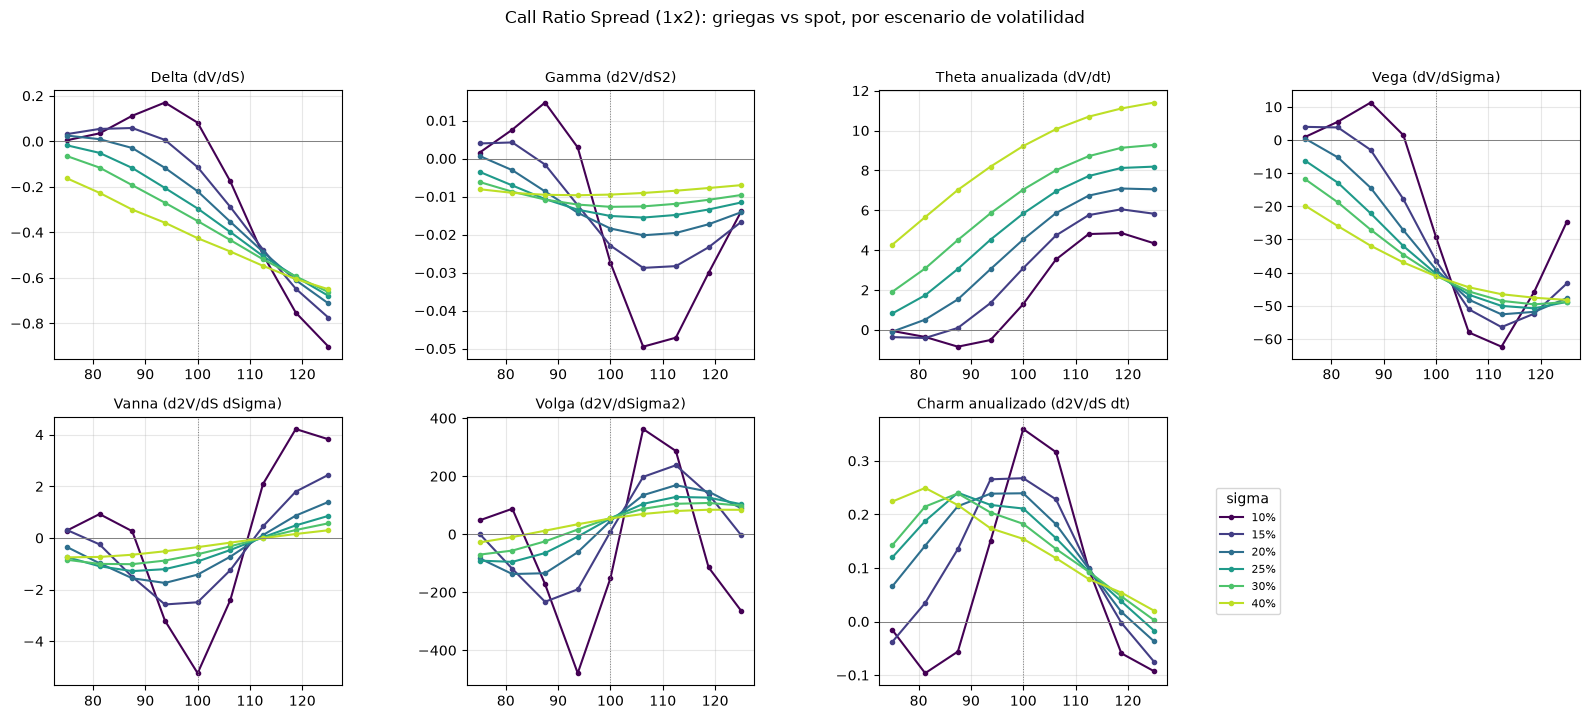

**Observado (spot=ATM=100, sigma=20%):** delta=-0.220, gamma=-0.0184, theta_anual=+4.53, vega=-39.09, vanna=-1.420, volga=+45.670, charm_anual=+0.239.

In [18]:
grids_call_ratio_spread = analyze_strategy("call_ratio_spread", "Call Ratio Spread (1x2)")

### `short_ratio_spread` -- espejo: corto C100, largo 2x C110

Sesgo bajista/neutral moderado con ganancia CRECIENTE sin limite muy al alza (2 calls compradas
dominan), perdida limitada si el spot cae. Gamma/vega netas probablemente POSITIVAS mas alla de
110 -- posicion neta LARGA de volatilidad mas alla de K2, al contrario que `call_ratio_spread`.

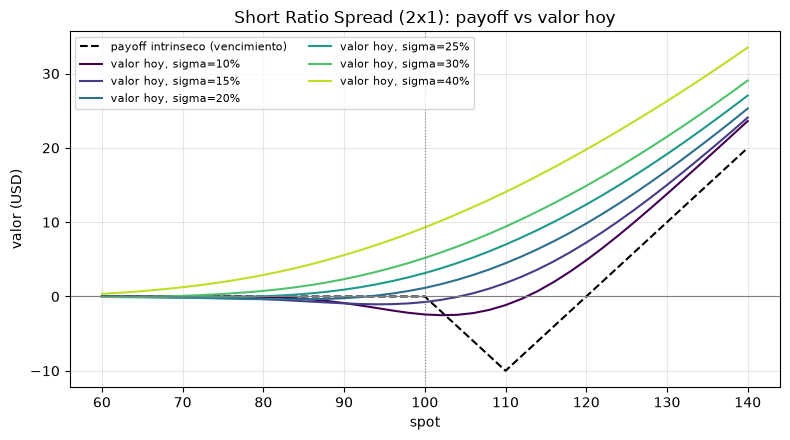

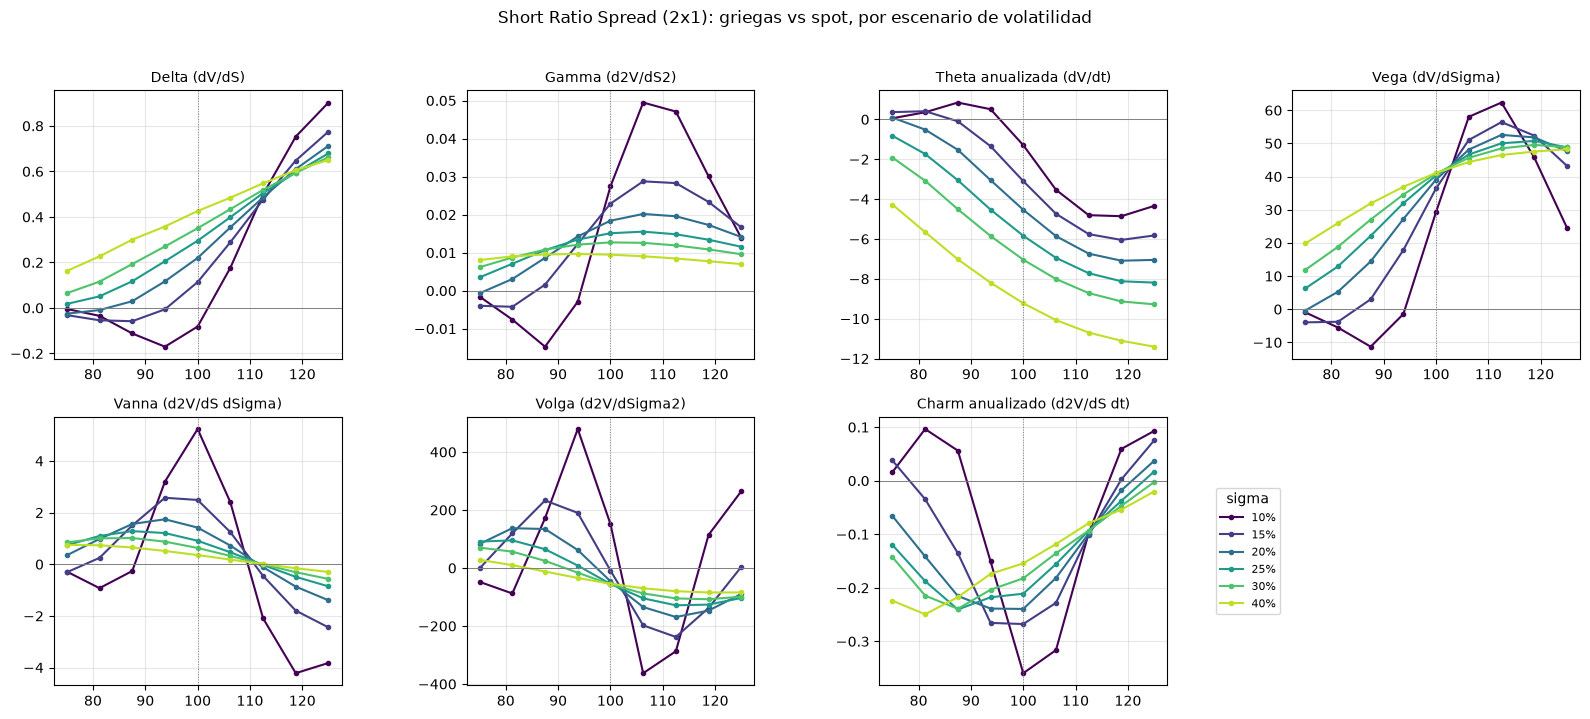

**Observado (spot=ATM=100, sigma=20%):** delta=+0.220, gamma=+0.0184, theta_anual=-4.53, vega=+39.09, vanna=+1.420, volga=-45.670, charm_anual=-0.239.

In [19]:
grids_short_ratio_spread = analyze_strategy("short_ratio_spread", "Short Ratio Spread (2x1)")

## Resumen: exposicion neta de cada estrategia en el escenario base (spot=ATM=100, sigma=20%)

Tabla comparativa de las 7 griegas de todas las estrategias en el mismo punto (spot, vol) para
poder leerlas en paralelo -- confirma (o no) las direcciones esperadas en el analisis previo de
cada una.

In [20]:
import pandas as pd

base_vi = VOLS.index(VOL_BASE)
atm_si = int(np.argmin(np.abs(SPOT_GRID_GREEKS - S0)))

rows = []
for name, var_name in [(n, f"grids_{n}") for n in STRATEGY_ORDER]:
    grids = globals()[var_name]
    rows.append({
        "estrategia": STRATEGY_TITLES[name],
        "delta": grids["delta"][base_vi, atm_si],
        "gamma": grids["gamma"][base_vi, atm_si],
        "theta_anual": grids["theta"][base_vi, atm_si],
        "vega": grids["vega"][base_vi, atm_si],
        "vanna": grids["vanna"][base_vi, atm_si],
        "volga": grids["volga"][base_vi, atm_si],
        "charm_anual": grids["charm"][base_vi, atm_si],
    })
summary_df = pd.DataFrame(rows).set_index("estrategia").round(4)
summary_df

,delta,gamma,theta_anual,vega,vanna,volga,charm_anual
estrategia,,,,,,,
Buy Call,0.6015,0.0180,-5.3960,38.7194,-0.5379,-103.4214,-0.0482
Sell Call,-0.6015,-0.0180,5.3960,-38.7194,0.5379,103.4214,0.0482
Buy Put,-0.3987,0.0199,-2.4762,38.6359,-0.2386,41.4705,-0.0481
Sell Put,0.3987,-0.0199,2.4762,-38.6359,0.2386,-41.4705,0.0481
Long Straddle,0.2028,0.0379,-7.8721,77.3553,-0.7765,-61.9509,-0.0964
Short Straddle,-0.2028,-0.0379,7.8721,-77.3553,0.7765,61.9509,0.0964
Long Butterfly,-0.0110,-0.0044,0.9777,-8.8627,0.1687,79.5044,-0.0043
Short Butterfly,0.0110,0.0044,-0.9777,8.8627,-0.1687,-79.5044,0.0043
Long Condor,-0.0093,-0.0081,1.7547,-16.1506,0.3400,128.7536,-0.0147


## Conclusion

La tabla de arriba deberia mostrar, de forma cualitativa: signos de vega opuestos entre
straddle/butterfly (apostar A FAVOR vs EN CONTRA de la vol), theta con signo tipicamente opuesto
al de vega dentro de cada par largo/corto (comprar opcionalidad cuesta tiempo, venderla lo cobra
-- salvo en los calendarios, donde la relacion theta/vega es mas sutil por la estructura
temporal), y los ratio spreads con el perfil asimetrico esperado (delta que cambia de signo lejos
del strike comprado). Cualquier discrepancia entre esta tabla y el analisis previo de una
estrategia concreta es una senal de que vale la pena revisar esa seccion con mas detalle (ruido
Monte Carlo de `n_paths` moderado, o una intuicion que necesita matizarse).